# Archivos de Metafluor

Los archivos de Metafluor son un formato de archivo comúnmente utilizado en microscopía y análisis de imágenes. Estos archivos contienen datos de imágenes y metadatos asociados capturados con software de adquisición de imágenes Metafluor. Los datos pueden incluir secuencias de imágenes en 2D o 3D, así como información sobre la configuración del microscopio, tiempos de exposición, canales de fluorescencia y más. Los archivos de Metafluor son imágenes "tif" y pueden contener una gran cantidad de información valiosa para el análisis y la visualización de datos de imágenes.

## Fluorescencia relativa

La fluorescencia relativa ($W_1/W_2$) se refiere a la relación entre las intensidades de fluorescencia medidas en dos longitudes de onda específicas, denominadas $W_1$ y $W_2$). Esta relación se utiliza para obtener información cuantitativa sobre una muestra fluorescente y puede proporcionar datos importantes sobre varios aspectos de interés.

Cuando se mide la fluorescencia de una muestra en diferentes longitudes de onda, puede haber componentes de fluorescencia que contribuyen de manera diferente a cada longitud de onda. La relación de fluorescencia relativa ($W_1/W_2$) permite comparar la intensidad de fluorescencia en las dos longitudes de onda y obtener una medida relativa de la cantidad de una determinada molécula o fluoróforo presente en la muestra.

La fluorescencia relativa se calcula dividiendo la intensidad de fluorescencia medida en la longitud de onda $W_1$ entre la intensidad de fluorescencia medida en la longitud de onda $W_2$. Esta relación puede proporcionar información sobre varios procesos, como la transferencia de energía entre moléculas fluorescentes (FRET), cambios conformacionales de proteínas marcadas con fluoróforos, concentración relativa de especies fluorescentes y más.

$\frac {V}{V_0} = \frac {\frac {W_1}{W_2} - f_b}{1 - f_b}$



## Carga de módulos, librerías e instalación de software

El código  está destinado a cargar y analizar archivos de Metafluor en un entorno de Google Colab. Aquí hay un resumen de lo que hará el código en general:

1. **Importación de módulos y librerías:** El código comienza importando las librerías necesarias para realizar el análisis de archivos de Metafluor. Estas librerías incluyen herramientas para visualización de datos, procesamiento de imágenes, análisis científico y más. Se establecen configuraciones y estilos personalizados para las gráficas generadas.

2. **Procesamiento de imágenes:** Se importan las librerías necesarias para el procesamiento de imágenes, como la biblioteca PIL (Python Imaging Library), OpenCV y imageio. Estas librerías proporcionan funcionalidades para leer, manipular y procesar imágenes, lo cual es especialmente útil para el análisis de datos de imágenes capturadas con Metafluor.

3. **Instalación de la librería OIFFILE:** Se instala y se importa la librería "oiffile", que es un lector de archivos TIFF específicos de Metafluor. Esta librería permite leer y extraer datos de archivos de Metafluor en formato TIFF.

4. **Ciencia y matemáticas:** Se importan las librerías científicas y matemáticas necesarias, como scipy, para realizar cálculos y análisis científicos adicionales en los datos de imágenes.

5. **Configuración y montaje de Google Drive:** Se configuran opciones adicionales, como la conexión y montaje de la carpeta de Google Drive, lo que permitirá acceder a los archivos almacenados en Google Drive desde el entorno de Google Colab.

In [ ]:
# === INICIO DE CARGA DE LIBRERÍAS ===
print('📦 Inicio de carga de librerías...')

# Librerías generales para Jupyter Lab
import os
import math
import random
import warnings
from datetime import datetime

# Visualización y widgets interactivos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Procesamiento y análisis
import numpy as np
import pandas as pd
import glob

# Procesamiento de imágenes
from PIL import Image
import cv2 as cv
import imageio

# Ciencia y matemática
import scipy
from scipy import ndimage as ndi
from scipy import stats

# Silenciar warnings innecesarios
warnings.filterwarnings("ignore")

# Estilo para matplotlib
%matplotlib inline
sns.set(style='white')
plt.rcParams.update({
    'text.usetex': False,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'axes.titlesize': 9
})

# Función utilitaria para convertir timestamps
def datefromunix(unix):
    """Convierte un timestamp UNIX a una fecha legible"""
    try:
        return datetime.utcfromtimestamp(unix).strftime('%d-%m-%Y %H:%M:%S')
    except Exception as e:
        print(f"Error convirtiendo timestamp: {e}")
        return None

# Verificar si oiffile está instalado
try:
    import oiffile
except ImportError:
    raise ImportError("⚠️ El módulo 'oiffile' no está instalado. Instálalo con: pip install oiffile")

print('✅ Librerías cargadas correctamente')
# === FIN DE CARGA DE LIBRERÍAS ===


Inicio de carga de librerías
Librerías generales
Procesamiento de imágenes
Instalando OIFFILE e importando el módulo, un lector de archivos TIFF
Ciencia y matemática
Fin de carga de librerías
Cargar la carpeta de Google Drive
Mounted at /content/drive


## Configurar las carpetas donde están los archivios.

Prestar atención y no editar a ciegas.

In [ ]:
from pathlib import Path

# Rutas a las carpetas con imágenes
carpeta_w1 = Path("/ruta/a/W1")  # <- CAMBIAR esta ruta según corresponda
carpeta_w2 = Path("/ruta/a/W2")  # <- CAMBIAR esta ruta según corresponda

def contar_archivos_en_carpeta(carpeta: Path, extensiones={".tif", ".tiff", ".png", ".jpg"}):
    """Cuenta los archivos válidos en una carpeta dada"""
    if not carpeta.exists():
        print(f"❌ Carpeta no encontrada: {carpeta}")
        return 0
    archivos = [f for f in carpeta.iterdir() if f.suffix.lower() in extensiones and f.is_file()]
    print(f"📂 Carpeta {carpeta} contiene {len(archivos)} archivos válidos.")
    return archivos

# Listar y contar archivos de cada carpeta
archivos_w1 = contar_archivos_en_carpeta(carpeta_w1)
archivos_w2 = contar_archivos_en_carpeta(carpeta_w2)


Carpeta de W1 /content/drive/MyDrive/Microscopia/E5/W1 con 244 archivos
Carpeta de W2 /content/drive/MyDrive/Microscopia/E5/W2 con 244 archivos


Dado que las imágenes del microscopio están separados en archivos individuales, si bien se pueden procesar por separado a veces conviene combinarlos en un solo archivo. Por ejemplo si lo quiero leer posteriormente con ImageJ, Fiji o cualquier otro.

In [ ]:
def cargar_imagenes_desde_carpeta(carpeta: Path) -> np.ndarray:
    """
    Carga todas las imágenes de una carpeta como un array 3D [frames, Y, X].
    Retorna una excepción si hay errores o inconsistencia.
    """
    archivos = sorted([f for f in carpeta.iterdir() if f.suffix.lower() in {".tif", ".tiff", ".png", ".jpg"}])
    
    if not archivos:
        raise FileNotFoundError(f"No se encontraron imágenes en {carpeta}")

    imagenes = []
    for i, archivo in enumerate(archivos):
        img = cv.imread(str(archivo), cv.IMREAD_UNCHANGED)
        if img is None:
            raise ValueError(f"Error al leer imagen: {archivo}")
        imagenes.append(img)

    stack = np.array(imagenes)

    print(f"📂 {carpeta.name} cargado: {stack.shape[0]} frames de tamaño {stack.shape[1]}x{stack.shape[2]}")
    return stack


# === CARGA DE IMÁGENES ===
print("📥 Cargando imágenes de W1 y W2...")

w1_img = cargar_imagenes_desde_carpeta(carpeta_w1)
w2_img = cargar_imagenes_desde_carpeta(carpeta_w2)

# === VALIDACIÓN DE COMPATIBILIDAD ===
if w1_img.shape != w2_img.shape:
    raise ValueError(f"Las imágenes de W1 y W2 no tienen la misma forma: {w1_img.shape} vs {w2_img.shape}")

# === CÁLCULO DE LA RELACIÓN W1/W2 ===
print("⚙️ Calculando la relación W1/W2...")

# Cálculo seguro para evitar división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    w1_w2 = np.divide(w1_img, w2_img, out=np.zeros_like(w1_img, dtype=np.float32), where=w2_img != 0)

# === INFORMACIÓN DE LA IMAGEN RESULTANTE ===
print(f"✅ Imagen W1/W2 calculada: {w1_w2.shape[0]} frames, tamaño {w1_w2.shape[1]}x{w1_w2.shape[2]}")
print(f"Número total de elementos: {w1_w2.size}, dimensiones: {w1_w2.ndim}, tamaño por elemento: {w1_w2.itemsize} bytes")


Cargando la carpeta /content/drive/MyDrive/Microscopia/E5/W1
Información de la imagen unificada de la /content/drive/MyDrive/Microscopia/E5/W1: cantidad de imágenes (ahora frames o tiempo) 244, coordenada Y: 256, coordenada X: 320

Cargando la carpeta /content/drive/MyDrive/Microscopia/E5/W1
Información de la imagen unificada de la /content/drive/MyDrive/Microscopia/E5/W2 frames: 244, Y: 256, X: 320

Calculando W1/W2 para obtener la relación de intensidades...
Información de la imagen de W1/W2: cantidad de frames 244, dimensiones Y: 256, dimensiones X: 320
Número de dimensiones (o axes): 3, número total de elementos en la imagen 19988480,  tamaño (bytes) de cada elemento 8


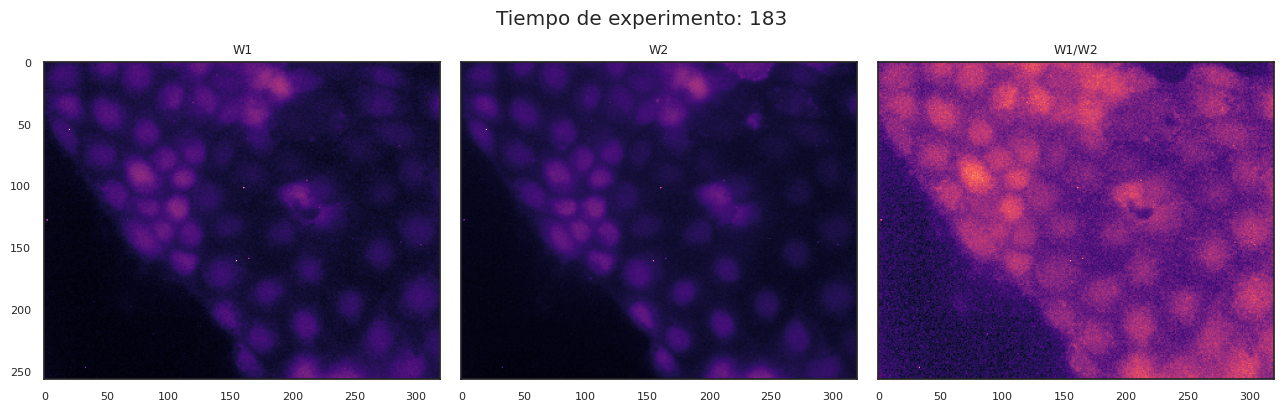

In [ ]:
# Parámetros de visualización
tema_seleccionado = "magma"  # Elegí entre los disponibles
time_experiment = 183        # Asegurate de que esté dentro del rango válido

# Validación del frame
num_frames = w1_img.shape[0]
if not (0 <= time_experiment < num_frames):
    raise ValueError(f"❌ El tiempo seleccionado ({time_experiment}) está fuera de rango (0 - {num_frames - 1})")

# Gráfico comparativo
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(13, 4))
fig.suptitle(f'Tiempo de experimento: frame {time_experiment}', fontsize=12)

ax[0].imshow(w1_img[time_experiment], cmap=tema_seleccionado)
ax[0].set_title('W1')
ax[0].axis('off')

ax[1].imshow(w2_img[time_experiment], cmap=tema_seleccionado)
ax[1].set_title('W2')
ax[1].axis('off')

ax[2].imshow(w1_w2[time_experiment], cmap=tema_seleccionado)
ax[2].set_title('W1 / W2')
ax[2].axis('off')

plt.tight_layout()
plt.show()


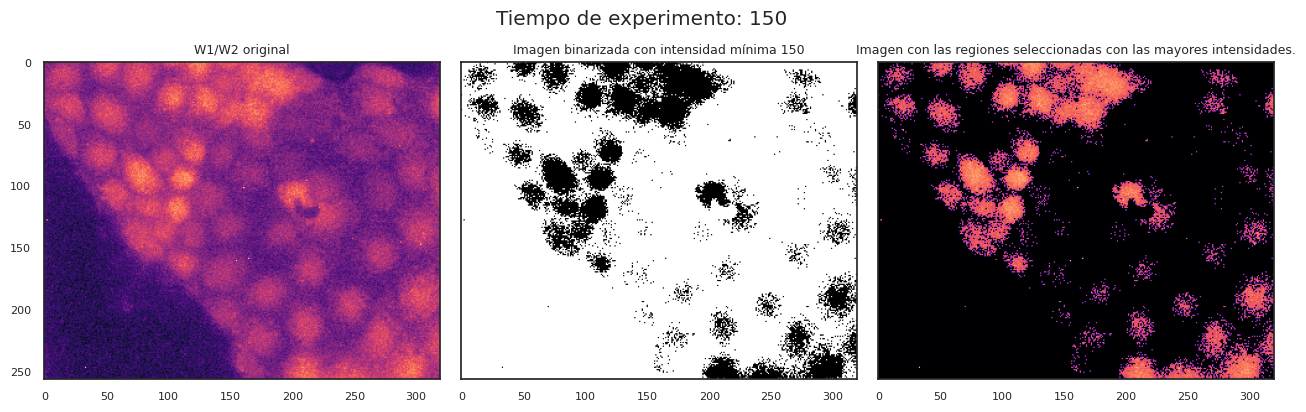

In [ ]:
# Parámetros configurables
tema_seleccionado = "magma"   # Colormap para visualización
time_experiment = 150         # Frame a observar
umbral_bin = 150              # Umbral mínimo para binarización (0–255)

# Validación de frame
if not (0 <= time_experiment < w1_w2.shape[0]):
    raise ValueError(f"❌ El frame {time_experiment} está fuera del rango válido (0 – {w1_w2.shape[0] - 1})")

# Extraer imagen correspondiente al tiempo
imagen_gris = w1_w2[time_experiment]

# Evitar división por cero si la imagen está vacía
max_val = np.max(imagen_gris)
if max_val == 0:
    raise ValueError("❌ La imagen está vacía (todos ceros), no se puede escalar a 8 bits.")

# Escalar a 8 bits (0-255) para visualización y umbralización
imagen_gris_8bits = (imagen_gris / max_val * 255).astype(np.uint8)

# Aplicar umbral binario
_, imagen_umbral = cv.threshold(imagen_gris_8bits, umbral_bin, 255, cv.THRESH_BINARY)

# (Opcional) Detectar contornos
contornos, jerarquia = cv.findContours(imagen_umbral, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Aplicar máscara a la imagen original (en escala flotante)
imagen_seleccionada = cv.bitwise_and(imagen_gris, imagen_gris, mask=imagen_umbral)

# Visualización
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(13, 4))
fig.suptitle(f'Tiempo de experimento: Frame {time_experiment}', fontsize=12)

# Imagen original en 8 bits
ax[0].imshow(imagen_gris_8bits, cmap=tema_seleccionado)
ax[0].set_title('W1/W2 original (8 bits)')
ax[0].axis('off')

# Imagen binarizada
ax[1].imshow(imagen_umbral, cmap='gray_r')
ax[1].set_title(f'Binarizada (umbral: {umbral_bin})')
ax[1].axis('off')

# Imagen con intensidades seleccionadas
ax[2].imshow(imagen_seleccionada, cmap=tema_seleccionado)
ax[2].set_title('Intensidades seleccionadas')
ax[2].axis('off')

plt.tight_layout()
plt.show()


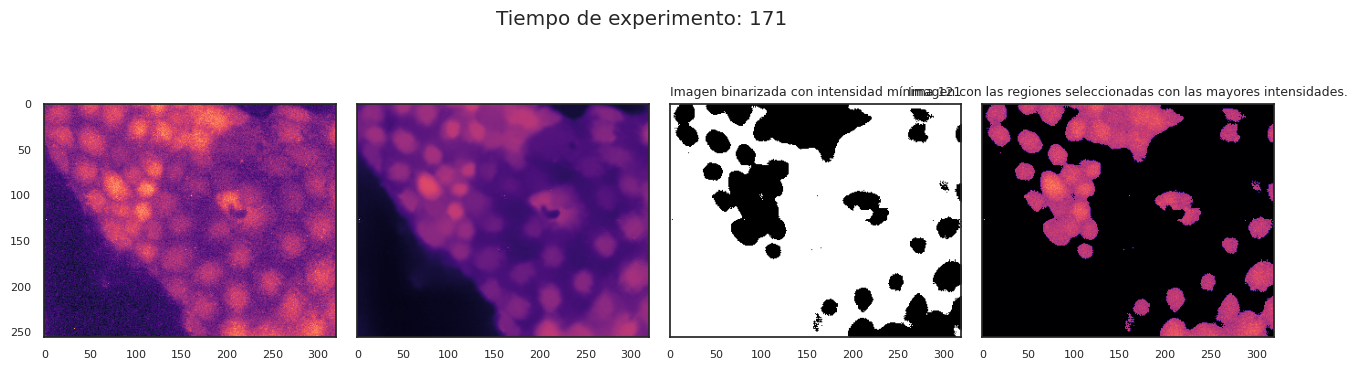

In [ ]:
# Parámetros configurables
tema_seleccionado = "magma"
time_experiment = 171
umbral_bin = 121
filtro_fuerza = 9  # Fuerza del filtro de eliminación de ruido

# Validación del frame
if not (0 <= time_experiment < w1_w2.shape[0]):
    raise ValueError(f"❌ El frame {time_experiment} está fuera del rango (0 – {w1_w2.shape[0] - 1})")

# Obtener imagen base
imagen_float = w1_w2[time_experiment]

# Validar que no sea toda ceros
max_val = np.max(imagen_float)
if max_val == 0:
    raise ValueError("❌ Imagen vacía, todos los valores son cero.")

# Escalar a 8 bits
imagen_8bits = (imagen_float / max_val * 255).astype(np.uint8)

# Aplicar suavizado (Non-local Means Denoising)
imagen_suavizada = cv.fastNlMeansDenoising(imagen_8bits, None, h=filtro_fuerza, templateWindowSize=7, searchWindowSize=21)

# Umbralizar imagen suavizada
_, imagen_umbral = cv.threshold(imagen_suavizada, umbral_bin, 255, cv.THRESH_BINARY)

# Encontrar contornos (opcional si luego se desea visualizarlos)
contornos, jerarquia = cv.findContours(imagen_umbral, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Aplicar máscara sobre imagen original (float)
imagen_seleccionada = cv.bitwise_and(imagen_float, imagen_float, mask=imagen_umbral)

# === VISUALIZACIÓN ===
fig, ax = plt.subplots(1, 4, figsize=(15, 4), sharex=True, sharey=True)
fig.suptitle(f'Suavizado y selección en frame {time_experiment}', fontsize=12)

ax[0].imshow(imagen_8bits, cmap=tema_seleccionado)
ax[0].set_title('Original (8 bits)')
ax[0].axis('off')

ax[1].imshow(imagen_suavizada, cmap=tema_seleccionado)
ax[1].set_title(f'Suavizada (h={filtro_fuerza})')
ax[1].axis('off')

ax[2].imshow(imagen_umbral, cmap='gray_r')
ax[2].set_title(f'Binarizada (umbral={umbral_bin})')
ax[2].axis('off')

ax[3].imshow(imagen_seleccionada, cmap=tema_seleccionado)
ax[3].set_title('Intensidades seleccionadas')
ax[3].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import imageio

# === PARÁMETROS DE USUARIO ===
tema_seleccionado = "magma"
velocidad = 14  # FPS
calidad_video = 10  # 1 (baja) a 20 (alta)
output_video_file = "animacion2D_W1W2.mp4"

# Validaciones
if not output_video_file.endswith((".mp4", ".avi", ".mov")):
    raise ValueError("El nombre del archivo de salida debe tener una extensión válida (.mp4, .avi, .mov)")

if not (1 <= velocidad <= 60):
    raise ValueError("Velocidad de cuadros por segundo fuera de rango (1-60)")

if not (1 <= calidad_video <= 20):
    raise ValueError("Calidad de video fuera de rango (1-20)")

# === GENERACIÓN DE VIDEO ===
print(f"🎞️ Generando video: {output_video_file}")
imagenes_animacion = []

for i in tqdm(range(w1_w2.shape[0]), desc="Generando frames"):
    fig, ax = plt.subplots(figsize=(3, 2), dpi=100)
    ax.axis('off')
    ax.imshow(w1_w2[i], cmap=tema_seleccionado)
    
    # Renderizar la imagen como array
    fig.canvas.draw()
    frame = np.array(fig.canvas.renderer.buffer_rgba())
    imagenes_animacion.append(frame)

    plt.close(fig)

# Guardar el video con parámetros para compatibilidad universal
imageio.mimsave(
    output_video_file,
    imagenes_animacion,
    fps=velocidad,
    quality=calidad_video,
    macro_block_size=None,
    codec="libx264",
    ffmpeg_params=["-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2"]  # aseguro dimensiones pares
)

print(f"✅ Video guardado como: {output_video_file}")


Inicio de generación del video animacion2Dotrotema.mp4 de W1/W2 en 2D
Fin de generación del video normal W1/W2


In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import imageio
import numpy as np
import cv2 as cv

# === PARÁMETROS DE USUARIO ===
tema_seleccionado = "plasma"
umbral_bin = 159
velocidad = 14
calidad_video = 7
output_video_file = "animacion2D_maxZonas.mp4"

# Validaciones
if not output_video_file.endswith((".mp4", ".avi", ".mov")):
    raise ValueError("❌ El nombre del archivo debe tener extensión .mp4, .avi o .mov")

if not (0 <= umbral_bin <= 255):
    raise ValueError("❌ El umbral debe estar entre 0 y 255")

if not (1 <= velocidad <= 60):
    raise ValueError("❌ Velocidad fuera de rango (1–60 fps)")

if not (1 <= calidad_video <= 20):
    raise ValueError("❌ Calidad fuera de rango (1–20)")

# === FUNCIÓN DE SELECCIÓN DE INTENSIDADES ALTAS ===
def selec_max(imagen_orig: np.ndarray, umbral: int) -> np.ndarray:
    if np.max(imagen_orig) == 0:
        return np.zeros_like(imagen_orig)

    # Escalar a 8 bits para aplicar umbral
    imagen_8bits = (imagen_orig / np.max(imagen_orig) * 255).astype(np.uint8)
    
    # Binarización simple
    _, imagen_umbral = cv.threshold(imagen_8bits, umbral, 255, cv.THRESH_BINARY)
    
    # Aplicar máscara
    imagen_seleccionada = cv.bitwise_and(imagen_orig, imagen_orig, mask=imagen_umbral)
    return imagen_seleccionada

# === GENERACIÓN DE VIDEO ===
print(f"🎞️ Generando video con intensidades mayores a {umbral_bin}: {output_video_file}")
imagenes_animacion = []

for i in tqdm(range(w1_w2.shape[0]), desc="Procesando frames"):
    imagen = selec_max(w1_w2[i], umbral=umbral_bin)

    fig, ax = plt.subplots(figsize=(3, 2), dpi=100)
    ax.axis('off')
    ax.imshow(imagen, cmap=tema_seleccionado)
    fig.canvas.draw()
    
    frame = np.array(fig.canvas.renderer.buffer_rgba())
    imagenes_animacion.append(frame)
    plt.close(fig)

# Guardar video
imageio.mimsave(
    output_video_file,
    imagenes_animacion,
    fps=velocidad,
    quality=calidad_video,
    macro_block_size=None,
    codec="libx264",
    ffmpeg_params=["-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2"]
)

print(f"✅ Video generado correctamente: {output_video_file}")


Comienzo de generación del video W1/W2 con las intensidades maximas
Fin de generación del video W1/W2 con las intensidades maximas


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import imageio
import cv2 as cv
from tqdm import tqdm

# === PARÁMETROS DEL USUARIO ===
tema_seleccionado = "magma"
velocidad = 11
calidad_video = 8
elevacion = 45
azimut = 70
output_video_file3d = "animacion3D_W1W2.mp4"

# === VALIDACIONES ===
if not output_video_file3d.endswith((".mp4", ".avi", ".mov")):
    raise ValueError("El archivo debe tener extensión .mp4, .avi o .mov")
if not (1 <= velocidad <= 60):
    raise ValueError("FPS fuera de rango (1–60)")
if not (1 <= calidad_video <= 20):
    raise ValueError("Calidad fuera de rango (1–20)")
if not (-90 <= elevacion <= 90):
    raise ValueError("Elevación fuera de rango (-90 a 90)")
if not (-90 <= azimut <= 90):
    raise ValueError("Azimut fuera de rango (-90 a 90)")

# === FUNCIÓN DE PREPROCESADO POR FRAME ===
def procesar_imagen_para_3d(imagen: np.ndarray) -> np.ndarray:
    if np.max(imagen) == 0:
        return np.zeros_like(imagen)
    imagen_8bit = (imagen / np.max(imagen) * 255).astype(np.uint8)
    return cv.fastNlMeansDenoising(imagen_8bit, None, 10, 7, 21)

# === GENERACIÓN DEL VIDEO ===
print(f"🎥 Generando video 3D en: {output_video_file3d}")
imagenes_animacion = []

for i in tqdm(range(w1_w2.shape[0]), desc="Procesando frames 3D"):
    imagen = procesar_imagen_para_3d(w1_w2[i])
    height, width = imagen.shape
    x = np.arange(width)
    y = np.arange(height)
    x_mesh, y_mesh = np.meshgrid(x, y)

    # === FIGURA ===
    fig = plt.figure(figsize=(5, 5), dpi=100)
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(x_mesh, y_mesh, imagen, cmap=tema_seleccionado, linewidth=0, antialiased=False)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Intensidad')
    ax.view_init(elev=elevacion, azim=azimut)

    fig.colorbar(surf, ax=ax, shrink=0.25, aspect=6)
    plt.tight_layout()

    # Render y captura del frame
    fig.canvas.draw()
    frame = np.array(fig.canvas.renderer.buffer_rgba())
    imagenes_animacion.append(frame)
    plt.close(fig)

# === GUARDAR VIDEO ===
imageio.mimsave(
    output_video_file3d,
    imagenes_animacion,
    fps=velocidad,
    quality=calidad_video,
    macro_block_size=None,
    codec="libx264"
)

print(f"✅ Video 3D guardado como: {output_video_file3d}")


Comienzo de generación del video 3D W1/W2 con las intensidades maximas
Fin de generación del video 3D W1/W2 con las intensidades maximas
